# Lab 3 – Automated Code Patching Analysis

Analyses results from `run_patching_lab.sh` across different mutation rates (0.0, 0.3, and 0.6).

Expected directory layout (relative to the repo root):
```
patching_results_0.0/  patching_results_Problem{N}.txt
patching_results_0.3/  patching_results_Problem{N}.txt
patching_results_0.6/  patching_results_Problem{N}.txt
instrumented/          Problem{N}.java (non-buggy ground truth)
```

In [4]:
import re
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Consistent style across all figures
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

RESULTS_ROOT = Path('..')
FIGURES_DIR  = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

PROBLEMS = [1, 4, 7, 11, 12, 15]
RATES    = ['0.0', '0.3', '0.6']

print('Results root:', RESULTS_ROOT.resolve())
print('Figures dir :', FIGURES_DIR.resolve())

Results root: /home/str/JavaInstrumentation
Figures dir : /home/str/JavaInstrumentation/analysis/figures


## 1 – Load Data and Parse Logs

In [5]:
def parse_log(path: Path):
    result = {
        'best_fitness': None,
        'generations': None,
        'patched_count': None,
        'convergence_gens': [],
        'convergence_fits': [],
        'patches': []
    }
    if not path.exists():
        return result
        
    text = path.read_text()
    
    m = re.search(r'Fitness:\s+([\d\.]+)', text)
    if m: result['best_fitness'] = float(m.group(1))
        
    m = re.search(r'Generation:\s+(\d+)', text)
    if m: result['generations'] = int(m.group(1))
        
    # Extract patches where old != new
    parsing_ops = False
    patched = 0
    for line in text.split('\n'):
        if line.startswith('Operators'):
            parsing_ops = True
            continue
        if parsing_ops and line.strip() == '':
            parsing_ops = False
            continue
        if parsing_ops:
            match = re.search(r'\[(\d+)\] (.*) -> (.*)', line)
            if match:
                idx = int(match.group(1))
                old_op = match.group(2).strip()
                new_op = match.group(3).strip()
                if old_op != new_op:
                    patched += 1
                    result['patches'].append((idx, new_op))
    result['patched_count'] = patched
    
    # Extract convergence
    parsing_conv = False
    for line in text.split('\n'):
        if line.startswith('Convergence'):
            parsing_conv = True
            continue
        if parsing_conv:
            parts = line.strip().split(',')
            if len(parts) == 2:
                result['convergence_gens'].append(int(parts[0]))
                result['convergence_fits'].append(float(parts[1]))
                
    return result

logs = {}
for r in RATES:
    for p in PROBLEMS:
        log_path = RESULTS_ROOT / f'patching_results_{r}' / f'patching_results_Problem{p}.txt'
        logs[(p, r)] = parse_log(log_path)
        
print("Loaded results for all rates and problems.")

Loaded results for all rates and problems.


## 2 – Summary Performance Statistics

In [6]:
rows = []
for p in PROBLEMS:
    for r in RATES:
        d = logs[(p, r)]
        rows.append({
            'Problem': f'Problem {p}',
            'Rate': r,
            'Best Fitness': d['best_fitness'] if d['best_fitness'] is not None else 'N/A',
            'Generations': d['generations'] if d['generations'] is not None else 'N/A',
        })

summary = pd.DataFrame(rows)
summary_pivot = summary.pivot(index='Problem', columns='Rate', 
                            values=['Best Fitness', 'Generations'])

pd.set_option('display.max_colwidth', 60)
display(summary_pivot)

Best Fitness                     Generations             
Rate                0.0       0.3       0.6         0.0    0.3   0.6
Problem                                                             
Problem 1      0.991885  1.000000  1.000000       239.0   57.0  18.0
Problem 11     0.840970  1.000000  1.000000       185.0   61.0  31.0
Problem 12     0.301092  0.539782  0.736349        58.0   64.0  67.0
Problem 15     0.974450  0.974450  0.974450         7.0    6.0   8.0
Problem 4      0.963973  0.993671  1.000000       116.0  126.0  89.0
Problem 7      0.984224  0.984224  0.984224        29.0   32.0  33.0

## 3 – Patch Correctness Analysis (Mutation Rate 0.6)

We parse the non-buggy RERS models to extract ground truth operators and compare them against the EA's patches.

In [ ]:
def extract_correct_operators(problem_id: int):
    path = RESULTS_ROOT / 'instrumented' / f'Problem{problem_id}.java'
    correct_ops = {}
    if not path.exists(): return correct_ops
        
    text = path.read_text()
    pattern = re.compile(r'OperatorTracker\.myOperator\("([^"]+)", [^,]+, [^,]+, (\d+)\)')
    for match in pattern.finditer(text):
        op = match.group(1)
        idx = int(match.group(2))
        correct_ops[idx] = '=='
    return correct_ops

patch_rows = []
for p in PROBLEMS:
    correct_ops = extract_correct_operators(p)
    d = logs[(p, '0.6')]
    
    total_patched = d['patched_count'] if d['patched_count'] is not None else 0
    correctly_patched = 0
    
    for idx, new_op in d['patches']:
        if idx in correct_ops and correct_ops[idx] == new_op:
            correctly_patched += 1
            
    patch_rows.append({
        'Problem': f'Problem {p}',
        'Best Fitness': d['best_fitness'],
        'Total Operators Patched': total_patched,
        'Correctly Patched': correctly_patched
    })
    
patch_df = pd.DataFrame(patch_rows).set_index('Problem')
display(patch_df)

,Best Fitness,Total Operators Patched,Correctly Patched
Problem,,,
Problem 1,1.000000,7,0
Problem 4,1.000000,32,0
Problem 7,0.984224,0,0
Problem 11,1.000000,34,0
Problem 12,0.736349,32,0
Problem 15,0.974450,0,0


## 4 – Fitness Convergence over Generations

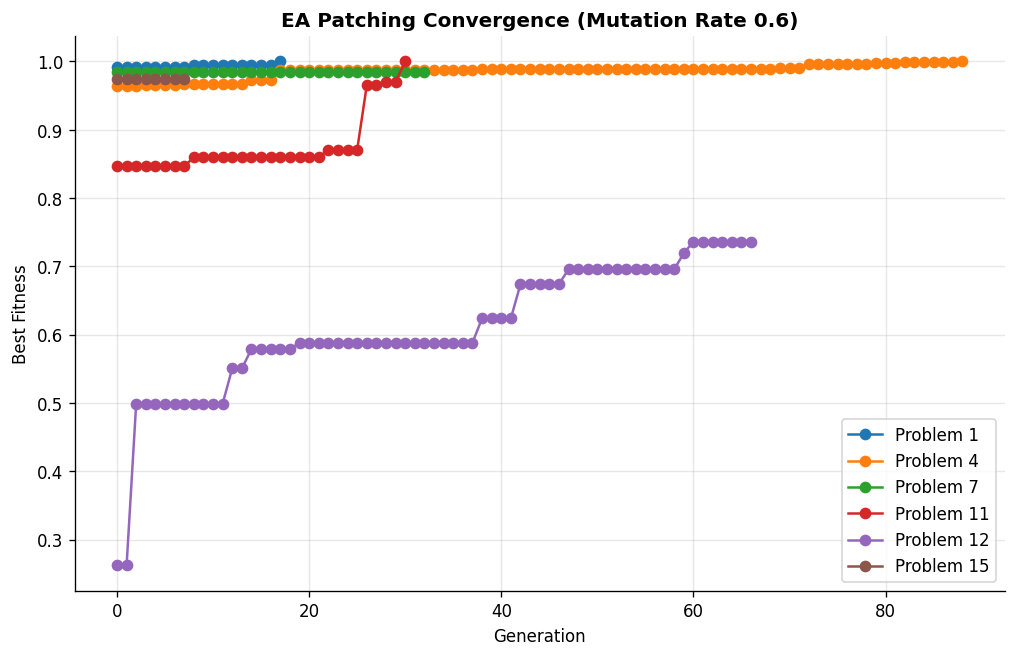

Saved: figures/patching_convergence.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

has_data = False
for p in PROBLEMS:
    d = logs[(p, '0.6')]
    if d['convergence_gens']:
        ax.plot(d['convergence_gens'], d['convergence_fits'], marker='o', linestyle='-', label=f'Problem {p}')
        has_data = True
        
ax.set_title('EA Patching Convergence (Mutation Rate 0.6)', fontweight='bold')
ax.set_xlabel('Generation')
ax.set_ylabel('Best Fitness')
ax.legend()

fig.savefig(FIGURES_DIR / 'patching_convergence.png', bbox_inches='tight')
plt.show()
print('Saved: figures/patching_convergence.png')